# 02. Replicating the CME FedWatch Tool

The [CME FedWatch tool](https://www.cmegroup.com/markets/interest-rates/cme-fedwatch-tool.html)
publishes the probability of each possible fed funds target range after
upcoming FOMC meetings, backed out of 30-Day Fed Funds futures (ZQ)
prices. It is one of the most-quoted numbers in financial journalism —
"markets price a 58% chance of a hike in September" is FedWatch talking.

This notebook replicates the tool's simplest case: the *next* scheduled
meeting, with a binary outcome — the Fed either leaves the target range
unchanged or moves once by 25 bps. That single case contains all of the
economic content; the full tool chains the same logic across later
meetings with a probability tree (out of scope here).

![CME FedWatch target rate probabilities](assets/fedwatch_target_probabilities.png)

*The published FedWatch tool for the September 16, 2026 meeting, captured
August 6, 2026. By the end of this notebook we will have reproduced this
chart from just two inputs: one futures price and one published rate.*

## From two numbers to a probability

Recall the settlement rule from notebook 01: the ZQ contract for a month
with $N$ calendar days settles at $100 - \bar{r}$, where $\bar{r}$ is the
month's calendar-day average of the effective federal funds rate (EFFR).
Before the month is over, the contract trades at the market's forecast of
$\bar{r}$, so a price $P$ observed today reveals an **expected average
rate**, $R = 100 - P = \mathbb{E}[\bar{r}]$. (Strictly a futures price
can also embed a risk premium; over the couple of months ahead of a
meeting it is small, FedWatch ignores it, and so do we.)

**Step 1 — the current rate is published every morning.** The pre-meeting
rate needs no model at all: the fed funds rate only moves when the FOMC
moves it, and the New York Fed publishes each day's realized EFFR the
next morning (we pull it from FRED). That latest print — call it
$r_{\text{pre}}$ — is the rate the market expects to prevail right up to
decision day. The published FedWatch tool anchors here too.

**Step 2 — the meeting-month contract averages two rates.** The decision
is announced on day $d$ of the $N$-day meeting month and takes effect the
next day, so the month's average straddles the decision: $d$ days accrue
at the known $r_{\text{pre}}$, and the remaining $N - d$ days accrue at
the post-meeting rate $\tilde{r}_{\text{post}}$ — a *random variable*
today, because the meeting hasn't happened yet. Taking expectations of
the average, the contract's implied rate is a **day-weighted blend** with
exactly one unknown, $r_{\text{post}} \equiv \mathbb{E}[\tilde{r}_{\text{post}}]$:

$$ r_{\text{avg}} = \frac{d}{N}\, r_{\text{pre}} + \frac{N-d}{N}\, r_{\text{post}}
   \quad\Longrightarrow\quad
   r_{\text{post}} = \frac{r_{\text{avg}}\, N - r_{\text{pre}}\, d}{N - d}. $$

Read $r_{\text{post}}$ carefully: it is an expectation, not a possible
outcome. The Fed moves in 25 bp steps, so the realized post-meeting
rate will sit on that grid — but its *expectation* can land anywhere in
between, and exactly where it lands is what encodes the probabilities.

**Step 3 — an expectation between two outcomes is a probability.** Assume
the meeting either leaves the target alone or moves it once by 25 bps, in
the direction the data suggest:

$$ \tilde{r}_{\text{post}} =
   \begin{cases}
     r_{\text{pre}}          & \text{with probability } 1 - p, \\[2pt]
     r_{\text{pre}} + \Delta & \text{with probability } p,
   \end{cases} $$

with $\Delta = -0.25$ for a cut or $+0.25$ for a hike. Take the
expectation of this two-point distribution:

$$ r_{\text{post}} = (1-p)\, r_{\text{pre}} + p\,(r_{\text{pre}} + \Delta)
   = r_{\text{pre}} + p\, \Delta. $$

The expected change is the probability times the step size — so the
probability is the expected change *measured in units of one step*:

$$ p = \frac{\lvert r_{\text{post}} - r_{\text{pre}} \rvert}{0.25},
   \qquad p_{\text{no change}} = 1 - p. $$

The two sanity checks are the intuition: a zero gap means $p = 0$, a full
25 bp gap means $p = 1$, and in between $p$ is how far the expected rate
has traveled from "no change" toward "one full move." (Market noise can
push the gap slightly outside $[0, 0.25]$; the code clips $p$ to $[0,1]$.)

### The worked example — against the real tool

The September 2026 meeting ends September 16, and September has 30 days:
$d = 16$, $N = 30$. On August 5, 2026, the EFFR print was
$r_{\text{pre}} = 3.63\%$ and the September contract `ZQU6` closed at
96.30, implying $r_{\text{avg}} = 3.70\%$. Step 2:

$$ r_{\text{post}} = \frac{3.70 \times 30 - 3.63 \times 16}{30 - 16}
   = \frac{111.00 - 58.08}{14} = 3.78\%. $$

The expected change is $+15$ bps, so Step 3 gives
$p_{\text{hike}} = 15/25 = 60\%$ and 40% no change.

Notice what the day-weighting accomplished. The naive reading —
"September prices 3.70% against 3.63% today, 7 bps is a $7/25 = 28\%$
hike chance" — is wrong, because a September 16 hike affects only the
last 14 of September's 30 days. The monthly average *dilutes* the move by
$\tfrac{N-d}{N} = \tfrac{14}{30}$, and Step 2 exists to undo that
dilution: $7 \times \tfrac{30}{14} = 15$ bps — hence 60%, not 28%.

The FedWatch screenshot at the top, captured the next morning, showed
**54.5% hike / 45.5% no change** — the same call as our 60/40, about six
probability points apart. That gap is smaller than it looks: the solve
for $r_{\text{post}}$ amplifies pricing differences by
$N/(N-d) \approx 2.1$, so one basis point in the implied rate moves the
probability by roughly nine points. Six points is under a basis point of
price — about what official settlements versus daily closes, and an
intraday screenshot versus a previous-day close, account for.

### Fine print

- **Meetings near month-end.** Dividing by $N - d$ amplifies noise by
  $N/(N-d)$ — about $10\times$ for a meeting on day 27. When a meeting
  falls in the last ~3 days of a month, FedWatch reads the *next* month's
  contract instead, whose whole month accrues at the post-meeting rate;
  `fedwatch_monitor` does the same.
- **The mornings right after a decision.** For a day or two the latest
  EFFR print predates the new target taking effect, so Step 1's anchor
  can be stale; `fedwatch_monitor` flags those runs (`anchor_stale`).
- **Only two outcomes.** A meeting that might move 50 bps (March 2020)
  violates the binary model. The full tool allows richer outcome sets and
  chains meetings into a probability tree — the single-meeting case here
  is the atom it is built from.

## The same steps on live data

Load the three inputs: daily ZQ bars, the EFFR series, and the FOMC
calendar.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import fedwatch
import fedwatch_monitor
import pull_effr
import pull_fed_funds_futures

df = pull_fed_funds_futures.load_fed_funds_futures()
effr = pull_effr.load_effr()
meetings = fedwatch.load_fomc_meetings()
meetings.tail()

,meeting_start,meeting_end
11,2026-06-16,2026-06-17
12,2026-07-28,2026-07-29
13,2026-09-15,2026-09-16
14,2026-10-27,2026-10-28
15,2026-12-08,2026-12-09


**Steps 1 and 2 inputs.** Find the next undecided meeting, take the
latest EFFR print as $r_{\text{pre}}$, and read $r_{\text{avg}}$ off the
meeting-month contract.

In [2]:
as_of = df["date"].max()
meeting_end = fedwatch_monitor.next_undecided_meeting(meetings, as_of)
d, n = meeting_end.day, meeting_end.days_in_month

effr_date, r_pre = fedwatch_monitor.latest_effr(effr, as_of)

latest = fedwatch.latest_prices_by_contract(df)
contract = latest.set_index("contract_month").loc[pd.Period(meeting_end, freq="M")]
r_avg = fedwatch.implied_rate(contract["close"])

print(f"As of {as_of.date()}, the next FOMC decision is {meeting_end.date()}")
print(f"EFFR print for {effr_date.date()}  =>  r_pre = {r_pre:.4f}%")
print(f"{contract['symbol']} close {contract['close']:.4f}  =>  r_avg = {r_avg:.4f}%")

As of 2026-09-10, the next FOMC decision is 2026-09-16
EFFR print for 2026-09-10  =>  r_pre = 3.6300%
ZQU6 close 96.2900  =>  r_avg = 3.7100%


**Solve and convert.** The day-weighted solve gives the expected
post-meeting rate; its gap from $r_{\text{pre}}$, in units of 25 bps, is
the probability. The current target range is inferred by snapping
$r_{\text{pre}}$ to the 25 bp grid (EFFR trades inside the Fed's range,
so this is safe).

In [3]:
r_post = fedwatch.solve_post_meeting_rate(r_avg, r_pre, meeting_end)
probs_info = fedwatch.move_probability(r_pre, r_post)
lower, _ = fedwatch.current_target_range(r_pre)

print(
    f"Meeting ends day {d} of {n}  =>  "
    f"r_post = ({r_avg:.4f}*{n} - {r_pre:.4f}*{d}) / {n - d} = {r_post:.4f}%"
)
print(f"Expected change: {(r_post - r_pre) * 100:+.1f} bps => {probs_info['direction']}")
print(f"Current target range (inferred): {fedwatch.range_label(lower)} bps")
print(
    f"P({probs_info['direction']}) = |{r_post:.4f} - {r_pre:.4f}| / 0.25 "
    f"= {probs_info['p_move']:.1%}"
)
print(f"P(no change) = {probs_info['p_no_change']:.1%}")

Meeting ends day 16 of 30  =>  r_post = (3.7100*30 - 3.6300*16) / 14 = 3.8014%
Expected change: +17.1 bps => hike
Current target range (inferred): 350-375 bps
P(hike) = |3.8014 - 3.6300| / 0.25 = 68.6%
P(no change) = 31.4%


### The whole argument in one picture

The rate path is flat at $r_{\text{pre}}$ through decision day $d$, then
splits into the two outcomes the binary model allows. The dashed line is
the *expected* post-meeting rate from Step 2 — where it sits between the
branches **is** the probability. The dotted line is the one number the
contract actually prices: the day-weighted average of the expected path.

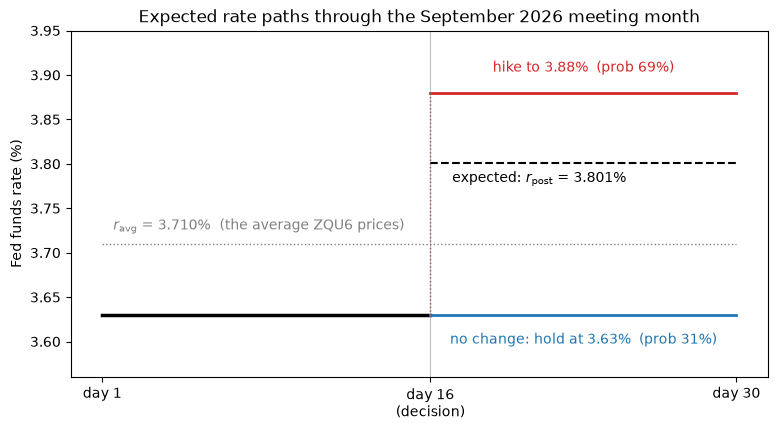

In [4]:
sgn = 1.0 if r_post >= r_pre else -1.0
r_moved = r_pre + sgn * 0.25
pad = 0.02

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot([1, d], [r_pre, r_pre], color="black", lw=2.5)
ax.plot([d, n], [r_pre, r_pre], color="tab:blue", lw=2)
ax.plot([d, d], [r_pre, r_moved], color="tab:red", lw=1, ls=":")
ax.plot([d, n], [r_moved, r_moved], color="tab:red", lw=2)
ax.hlines(r_post, d, n, color="black", lw=1.5, ls="--")
ax.hlines(r_avg, 1, n, color="gray", lw=1, ls=":")
ax.axvline(d, color="gray", lw=0.8, alpha=0.5)

mid = (d + n) / 2
ax.text(
    mid,
    r_pre - sgn * pad,
    f"no change: hold at {r_pre:.2f}%  (prob {probs_info['p_no_change']:.0%})",
    color="tab:blue",
    ha="center",
    va="top" if sgn > 0 else "bottom",
)
ax.text(
    mid,
    r_moved + sgn * pad,
    f"{probs_info['direction']} to {r_moved:.2f}%  (prob {probs_info['p_move']:.0%})",
    color="tab:red",
    ha="center",
    va="bottom" if sgn > 0 else "top",
)
ax.text(
    d + 1,
    r_post - sgn * pad / 2,
    f"expected: $r_\\mathrm{{post}}$ = {r_post:.3f}%",
    ha="left",
    va="top" if sgn > 0 else "bottom",
)
ax.text(
    1.5,
    r_avg + pad / 2,
    f"$r_\\mathrm{{avg}}$ = {r_avg:.3f}%  (the average {contract['symbol']} prices)",
    color="gray",
    ha="left",
    va="bottom",
)
ax.set_xticks([1, d, n], ["day 1", f"day {d}\n(decision)", f"day {n}"])
ax.set_ylim(min(r_pre, r_moved) - 0.07, max(r_pre, r_moved) + 0.07)
ax.set_ylabel("Fed funds rate (%)")
ax.set_title(f"Expected rate paths through the {meeting_end:%B %Y} meeting month")
plt.show()

## All at once

`fedwatch_monitor.compute_monitor_forecast` packages exactly the steps
above, plus the fine-print handling (the month-end contract switch and
the stale-anchor flag). It is what the pipeline's chart task and the
daily monitor (`doit monitor`) both call.

In [5]:
summary, probs = fedwatch_monitor.compute_monitor_forecast(df, effr, meetings)
probs

,outcome,target_range,probability
0,350-375 (no change),350-375,0.314286
1,375-400 (hike),375-400,0.685714


And the FedWatch-style chart (the pipeline writes this to
`_output/fedwatch_latest_forecast.png` and an interactive HTML version
for the chartbook site). Compare it with the screenshot at the top —
and remember that if you have refreshed the data since this case study
was written, the numbers will have moved with the market.

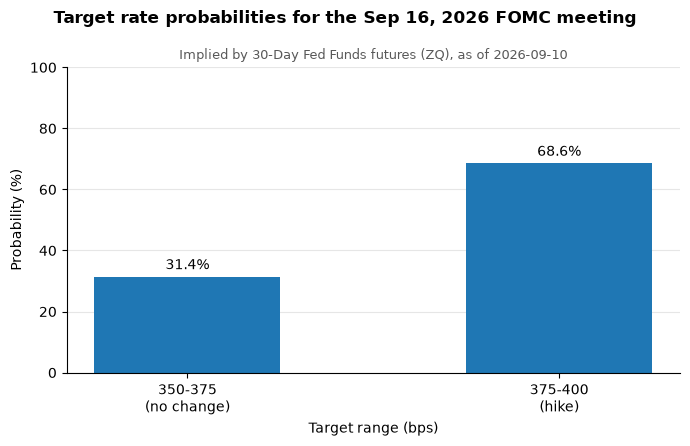

In [6]:
from fedwatch_chart import plot_probabilities_matplotlib

ax = plot_probabilities_matplotlib(summary, probs)
plt.show()

**Exercises**

1. Recompute the forecast with `as_of` set to the day before the *last*
   FOMC meeting (pass `as_of=` to `compute_monitor_forecast`). Did the
   market see the decision coming?
2. Plot `p_move` over time by looping `compute_monitor_forecast` over the
   as-of dates in the sample. When did the market's mind change? (This
   path-over-time view is exactly what `doit monitor` accumulates in
   `_data/fedwatch_history.parquet` going forward.)
3. EFFR can only anchor the *next* meeting: for the meeting after that,
   the pre-meeting rate is unknown today because it depends on the first
   decision. Argue that the first meeting's $r_{\text{post}}$ is the
   natural anchor for the second, and use it to extend the forecast one
   meeting further out. (You have just built the first branch of
   FedWatch's probability tree.)